# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

### Intro to the Dataset:
I have chosen a dataset that contains ecommerce data for ecommerce in the United States in the year 2020

### Who is the Audience for the Dataset
The dataset contains ecommerce data for the United States in the year 2020. Therefore, I believe the largest user of this dataset will be ecommerce companies who sell products in the United States. For example, an ecommerce company, such as Amazon, may analyze this data to see what products were selling well in the year 2020. Other potential users of this data may be logisitics and shipping companies, to see what states/cities were ordering the most online merchandise to help them plan shipping routes accordingly. Additionally, supply chain and manufacturing companies may also want to use this data to understand what states / cities were ordering the most products and what they were ordering. This could be helpful for them to understand where to build furuture manufacturing and supply plants. For example, Amazon may want to build warehouses near hubs of where customers are ordering merchandise to save money on shipping and transportation. 

### What do you need your audience to know or do
There are many useful insights that can be derived from this dataset. A few that will be found useful by the intended audience are:
* What products sold the best via ecommerce in the year 2020 (What category of products, sub-category or products, and individual products)
* What states (and subsequent cities) had the highest level of ecommerce sales in 2020
* When there was a discount applied to the sales price, did this lead to a higher sales volume in that period
* What months saw the largest volume of ecommerce
* Purchasing patterns of customer by region, state, city
* Purchasing patterns of repeat customers

### How will you communicate this to your audience
Communicating these insights to the intended audience is where data visualization becomes really useful. Understanding analytics and patterns in a dataset can be quite simple for analysts who can just query the data via SQL. However, for non-technical users, there can often be a knowledge gap here. The best way to communicate this to the audience will be through effective data visualization. For each of the potential insights outlined above, I will outline how they could be displayed via data visualization:
* What products sold the best: a bar chart outlinting products (or categories) and they sales volumes. Could also have a pie chart showing categories and sales percentage that belonged to each.
* What states had the most sales: a bar chart outlinting each state and their sales
* Sales increase with discount: could visualize the sales for a product in a period with no discount and a period with a discount: could do this with a line chart showing the sales over time when a discount was applied and no applied. Or could use a bar chart having two values (with discount and without) over time period or states or such.
* What months saw the largest volumes of ecommerce: a line chart plotting sales over time (months of the year)
* Purchasing patterns of customers per location: Could create a bar chart for each region and then break that bar into percentages of what categories users were shopping for in that region.
* Repeat customer patterns: can map which products saw the largest volume of repeat customers via a bar chart


# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [2]:
# Load the Data and look at the first few rows

ecommerce_data = pd.read_csv("ecommerce_data.csv")
ecommerce_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1/1/2020,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,1/1/2020,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,1/1/2020,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,1/1/2020,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,1/1/2020,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [3]:
# Check the columns and that they have the appropriate data types
ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

Many of the data types are all object type, some of these should be set to a new data type. For example, Order Date should be datetime data type. Additionally, the Order Date column has inconsistent formatting, that must be fixed to make the column consistent.

In [4]:
# Set the Order Date Column to be of Date Type

ecommerce_data['Order Date'] = pd.to_datetime(
    ecommerce_data['Order Date'],
    format='mixed',
    dayfirst=False,
    errors='coerce'
)

ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3312 non-null   datetime64[ns]
 1   Row ID        3312 non-null   int64         
 2   Order ID      3312 non-null   object        
 3   Ship Mode     3312 non-null   object        
 4   Customer ID   3312 non-null   object        
 5   Segment       3312 non-null   object        
 6   Country       3312 non-null   object        
 7   City          3312 non-null   object        
 8   State         3312 non-null   object        
 9   Postal Code   3312 non-null   int64         
 10  Region        3312 non-null   object        
 11  Product ID    3312 non-null   object        
 12  Category      3312 non-null   object        
 13  Sub-Category  3312 non-null   object        
 14  Product Name  3312 non-null   object        
 15  Sales         3312 non-null   float64 

In [5]:
# Check the Summary Statistics to get a Good Understanding of Data Values
# This will tell us the mean, median, and mode of all numerical columns
ecommerce_data.describe()

,Order Date,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,2020-07-14 23:33:54.782608896,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
min,2020-01-01 00:00:00,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2020-04-10 18:00:00,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,2020-07-23 00:00:00,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,2020-10-19 00:00:00,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,2020-12-30 00:00:00,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800
std,NaN,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342


The Ordere Date column has minimum and maximum values in 2020. Therefore, all of the dates in this dataset are in the year 2020 and thus, make sense. 

The minimum of the Postal Code column is 4 digits, which seems suspicous to me

In [6]:
# Checking that all of the data in this table is for the United States, 
# therefore, a postcal code with 4 digits is unexpected

ecommerce_data['Country'].unique()

array(['United States'], dtype=object)

In [7]:
# Since all data is in the US, all postal codes should be 5 digits, check every instance this is false

invalid_postcal_codes = []
for postal_code in ecommerce_data['Postal Code']:
    if postal_code < 10000:
        invalid_postcal_codes.append(postal_code)
    else:
        continue
print(len(invalid_postcal_codes))
print(invalid_postcal_codes)

149
[2169, 5408, 5408, 5408, 5408, 6708, 6824, 6824, 8861, 8861, 6457, 6457, 2138, 2138, 1852, 6824, 6824, 6824, 8701, 6457, 6457, 6450, 7060, 7060, 8901, 8901, 6708, 6708, 2908, 2908, 7960, 2908, 7050, 6040, 7090, 2149, 8360, 8360, 8360, 8360, 3301, 6360, 7109, 7109, 2920, 6460, 6460, 6460, 2169, 2169, 3301, 2886, 1852, 1852, 1852, 6040, 6040, 6040, 6040, 7060, 3301, 3301, 3301, 7060, 2740, 1841, 1841, 2038, 2038, 6450, 6450, 6450, 3060, 2908, 2908, 1841, 2895, 2895, 7050, 2149, 2149, 2149, 2149, 8701, 8701, 8701, 8701, 6708, 6708, 7960, 7960, 3301, 1841, 1841, 7109, 7109, 2920, 8701, 8701, 8701, 8701, 6824, 2886, 2886, 1841, 1841, 2920, 2920, 2920, 2920, 2920, 2920, 2149, 2149, 2149, 7090, 2149, 6824, 6824, 1852, 1852, 1852, 7501, 7501, 7501, 5408, 2920, 6824, 6824, 2740, 7501, 7060, 7060, 7060, 1841, 1841, 1841, 1841, 1841, 7501, 7501, 7501, 2908, 2908, 6457, 6810, 2740, 2740, 7017]


Since there are many values that are 4 digits, it is a reasonable conclusion that these values actually start with a leading 0. The leading 0 was removed because it is formatted as an int. Thus, the Postcal Code column should add back in leading 0s and then format this column as a string so that future postcal codes with a 0 are maintained.

In [8]:
# Switching the Postal Code to be a string data type
ecommerce_data['Postal Code'] = ecommerce_data['Postal Code'].astype('string')
ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3312 non-null   datetime64[ns]
 1   Row ID        3312 non-null   int64         
 2   Order ID      3312 non-null   object        
 3   Ship Mode     3312 non-null   object        
 4   Customer ID   3312 non-null   object        
 5   Segment       3312 non-null   object        
 6   Country       3312 non-null   object        
 7   City          3312 non-null   object        
 8   State         3312 non-null   object        
 9   Postal Code   3312 non-null   string        
 10  Region        3312 non-null   object        
 11  Product ID    3312 non-null   object        
 12  Category      3312 non-null   object        
 13  Sub-Category  3312 non-null   object        
 14  Product Name  3312 non-null   object        
 15  Sales         3312 non-null   float64 

In [9]:
# Adding back in a Leading 0 to all 4 digit zip codes
for postal_code in ecommerce_data['Postal Code']:
    if len(postal_code) == 4:
        ecommerce_data['Postal Code'] = "0" + postal_code
    else:
        continue

In [10]:
# Rechecking that there are no invalid values in the Postcal Code Column

for postal_code in ecommerce_data['Postal Code']:
    if len(postal_code) ==4:
        print(postal_code)
    else:
        continue

In [11]:
# Check for Duplicate values in the Row ID column

ecommerce_data[ecommerce_data['Row ID'].duplicated()]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [12]:
# Check for Duplicate values in the Order ID column

ecommerce_data[ecommerce_data['Order ID'].duplicated()]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
5,2020-01-01,8072,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,Central,FUR-CH-10003199,Furniture,Chairs,Office Star - Contemporary Task Swivel Chair,310.744,4,0.3,-26.6352
6,2020-01-01,8073,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,Central,OFF-AR-10003158,Office Supplies,Art,Fluorescent Highlighters by Dixon,12.736,4,0.2,2.2288
7,2020-01-01,8074,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,Central,OFF-BI-10000301,Office Supplies,Binders,GBC Instant Report Kit,6.470,5,0.8,-9.7050
8,2020-01-01,8075,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,Central,OFF-BI-10000343,Office Supplies,Binders,"Pressboard Covers with Storage Hooks, 9 1/2"" x...",13.748,14,0.8,-22.6842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3303,2020-12-29,7636,US-2017-158526,Second Class,KH-16360,Consumer,United States,Louisville,Kentucky,07017,South,FUR-CH-10004495,Furniture,Chairs,"Global Leather and Oak Executive Chair, Black",300.980,1,0.0,87.2842
3304,2020-12-29,7637,US-2017-158526,Second Class,KH-16360,Consumer,United States,Louisville,Kentucky,07017,South,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,258.750,3,0.0,77.6250
3307,2020-12-30,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,07017,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,2020-12-30,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,07017,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910


There are duplicate values in the Order ID column, but that is okay, because it is likely that Row ID is the primary key for this table and the uniqueness of a row is not determined by the Order ID, but by the Row ID and the then a composite key of different columns in the table (potentially: Order Date, Order ID, Customer ID, and Product Name)

In [13]:
# Check for null values in the Row ID column - This is likely the PK column, so should have no nulls

ecommerce_data[ecommerce_data['Row ID'].isna()]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [14]:
# Check for null values in the Order ID column

ecommerce_data[ecommerce_data['Order ID'].isna()]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [15]:
# All the columns are non-nullable, so they should all have 0 nulls. Checking this here

ecommerce_data.isna().any().any()

np.False_

Encoding Categorical Variables - First ensuring these columns are categorical, meaning they are made up of a set number of columns.

In [16]:
# Check that Category column is categorical
ecommerce_data['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [17]:
# Check that Sub_Category column is categorical
ecommerce_data['Sub-Category'].unique()

array(['Furnishings', 'Binders', 'Storage', 'Chairs', 'Art', 'Appliances',
       'Machines', 'Tables', 'Accessories', 'Paper', 'Supplies',
       'Fasteners', 'Envelopes', 'Bookcases', 'Phones', 'Labels',
       'Copiers'], dtype=object)

In [18]:
# Encoding the Category Column with One Hot Encoding
one_hot = pd.get_dummies(ecommerce_data['Category'])
ecommerce_data = ecommerce_data.join(one_hot)
ecommerce_data.iloc[0:5]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Furniture,Office Supplies,Technology
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,07017,...,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,True,False,False
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,07017,...,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,True,False,False
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,07017,...,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,False,True,False
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580,False,True,False
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,...,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815,True,False,False


In [19]:
# Encoding the Sub-Category Column with One Hot Encoding
one_hot = pd.get_dummies(ecommerce_data['Sub-Category'])
ecommerce_data = ecommerce_data.join(one_hot)
ecommerce_data.iloc[0:5]

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,...,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,07017,...,False,False,True,False,False,False,False,False,False,False
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,07017,...,False,False,True,False,False,False,False,False,False,False
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,07017,...,False,False,False,False,False,False,False,False,False,False
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,...,False,False,False,False,False,False,False,True,False,False
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,07017,...,False,False,True,False,False,False,False,False,False,False


In [20]:
# Checking that there is Class Balance in the Category Column

ecommerce_data['Category'].value_counts()

Category
Office Supplies    2002
Furniture           686
Technology          624
Name: count, dtype: int64

There are a significantly higher number of data points that fall into the office supplies category than those that fall into the furniture and technolocy categories

In [21]:
# Checking that there is Class Balance in the Sub-Category Column

ecommerce_data['Sub-Category'].value_counts()

Sub-Category
Binders        500
Paper          459
Furnishings    316
Phones         294
Storage        288
Art            282
Accessories    275
Chairs         190
Appliances     165
Labels         114
Tables         104
Bookcases       76
Envelopes       71
Fasteners       64
Supplies        59
Machines        33
Copiers         22
Name: count, dtype: int64

There is also a class imbalance in the sub-category column. This makes sense as many of the sub-categories that fall into the Office supplies Category have higher counts than those that fall into the furniture and technology categories.

Overall, there were a few ways that the data needed to be cleaned and transformed. Such as:
* Changing Order Date to a datetime column
* Adding leading zeros that had been removed to the Postal Code column
* Converting the Postal Code column to string type.
* Additionally, there is definetly a class imbalance in the categorical columns (Category and Sub-Category) in the table.


However, overall there are no null values in the table, no duplicate values in the primary key column, and the data is complete and sensible. Therefore, I believe this data is overall strong and well suited for reliable analysis.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [39]:
# Loading Example Data

non_profit_data = {
    "Year": [2010, 2011, 2012, 2013, 2014, 2015],
    "Arts and Culture": [35, 50, 42, 58, 48, 62],
    "Education": [55, 68, 60, 75, 70, 82],
    "Health": [65, 80, 72, 85, 78, 90],
    "Human Services": [62, 50, 58, 45, 52, 40],
    "Other": [24, 32, 28, 36, 30, 38],
}

non_profit_df = pd.DataFrame(non_profit_data)
non_profit_df


,Year,Arts and Culture,Education,Health,Human Services,Other
0,2010,35,55,65,62,24
1,2011,50,68,80,50,32
2,2012,42,60,72,58,28
3,2013,58,75,85,45,36
4,2014,48,70,78,52,30
5,2015,62,82,90,40,38


In [53]:
# Importing Matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

''

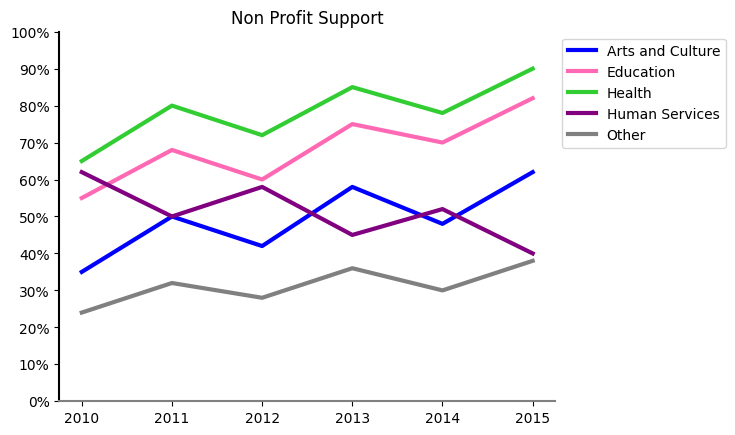

In [63]:
# Replicating the Non Profit Support Graph from Story Telling with Data

# Plotting each Category as a Line
plt.plot(non_profit_data["Year"], non_profit_data["Arts and Culture"], color="blue", linewidth=3, label="Arts and Culture")
plt.plot(non_profit_data["Year"], non_profit_data["Education"], color="hotpink", linewidth=3, label="Education")
plt.plot(non_profit_data["Year"], non_profit_data["Health"], color="limegreen", linewidth=3, label="Health")
plt.plot(non_profit_data["Year"], non_profit_data["Human Services"], color="purple", linewidth=3, label="Human Services")
plt.plot(non_profit_data["Year"], non_profit_data["Other"], color="grey", linewidth=3, label="Other")

# Set y-axis from 0 to 100
plt.ylim(0, 100)

# Set y-axis ticks every 10
plt.yticks(range(0, 101, 10))

# Format y-axis labels as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter())

# Only show left and bottom spines (hide top and right)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)   # optional: make axis lines thicker
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color('grey')

# Add the legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Add the Graph Title
plt.title("Non Profit Support")
;